<a href="https://colab.research.google.com/github/ChanggonSong/AI-Study/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
features = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/titanic.csv', index_col = 0)
features

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [4]:
# 결측치 개수 파악
# 셀 실행 결과를 데이터프레임으로 보고 싶을 때 to_frame()과 pd.DataFrame() 두 가지를 사용 가능
features.isnull().sum().to_frame('nan_count')

,nan_count
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


In [5]:
# 결측치 비율 파악
pd.DataFrame(data=features.isnull().sum()/len(features),columns=['nan_ratio'])

,nan_ratio
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,0.198653
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000
Cabin,0.771044


In [6]:
# 결측치가 있는 행을 제거
features = features[~features.isnull().any(axis=1)]

In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
features['Sex'] = le.fit_transform(features['Sex'])
features['Cabin'] = le.fit_transform(features['Cabin'])
features['Embarked'] = le.fit_transform(features['Embarked'])

features.head()

<ipython-input-7-05b09d80e81a>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['Sex'] = le.fit_transform(features['Sex'])
<ipython-input-7-05b09d80e81a>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['Cabin'] = le.fit_transform(features['Cabin'])
<ipython-input-7-05b09d80e81a>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.o

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,72,0
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,48,2
7,0,1,"McCarthy, Mr. Timothy J",1,54.0,0,0,17463,51.8625,117,2
11,1,3,"Sandstrom, Miss. Marguerite Rut",0,4.0,1,1,PP 9549,16.7000,131,2
12,1,1,"Bonnell, Miss. Elizabeth",0,58.0,0,0,113783,26.5500,43,2


In [8]:
y = features['Survived']
y

PassengerId
2      1
4      1
7      0
11     1
12     1
      ..
872    1
873    0
880    1
888    1
890    1
Name: Survived, Length: 183, dtype: int64

In [9]:
features.dtypes

Survived      int64
Pclass        int64
Name         object
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Ticket       object
Fare        float64
Cabin         int64
Embarked      int64
dtype: object

In [10]:
X=features.drop('Survived', axis=1)

In [11]:
X=X.drop('Ticket', axis=1)

In [12]:
X=X.drop('Name', axis=1)
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
PassengerId,,,,,,,,
2,1,0,38.0,1,0,71.2833,72,0
4,1,0,35.0,1,0,53.1000,48,2
7,1,1,54.0,0,0,51.8625,117,2
11,3,0,4.0,1,1,16.7000,131,2
12,1,0,58.0,0,0,26.5500,43,2
...,...,...,...,...,...,...,...,...
872,1,0,47.0,1,1,52.5542,91,2
873,1,1,33.0,0,0,5.0000,29,2
880,1,0,56.0,0,1,83.1583,61,0


In [13]:
passenger_target = y.to_numpy()
passenger_full = X.to_numpy()

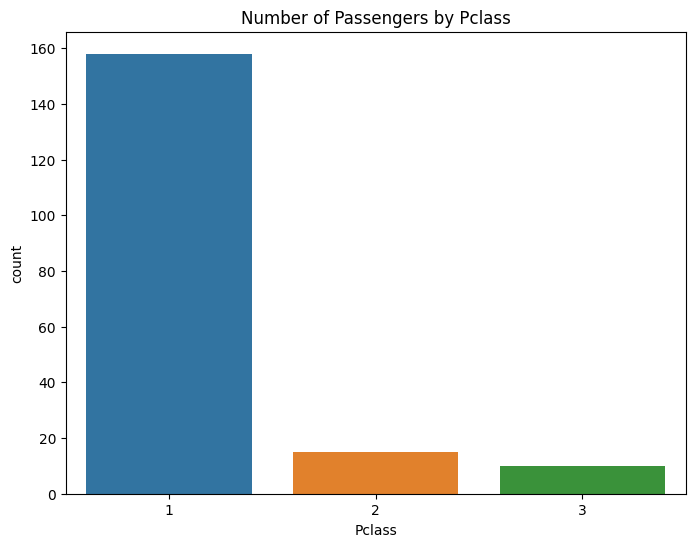

In [14]:
# 1. Pclass 레이블별 갯수 및 차트 표시
plt.figure(figsize=(8, 6))
sns.countplot(x='Pclass', data=features)
plt.title('Number of Passengers by Pclass')
plt.show()

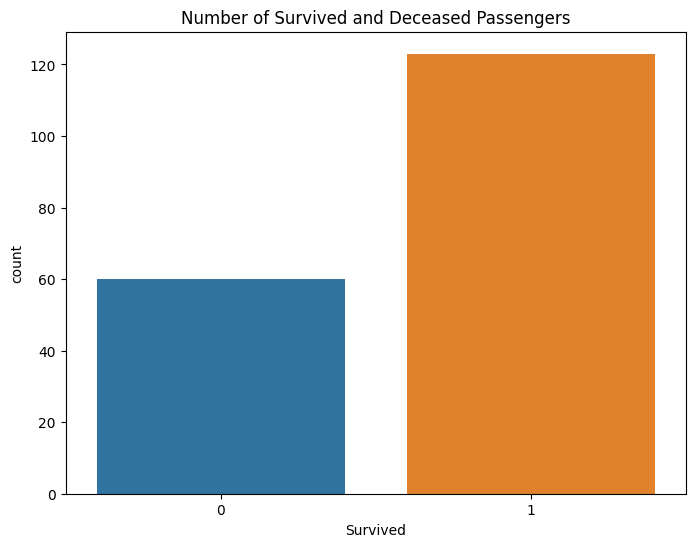

In [15]:
# 2. 생존자와 사망자 총 숫자 및 차트 표시
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived', data=features)
plt.title('Number of Survived and Deceased Passengers')
plt.show()

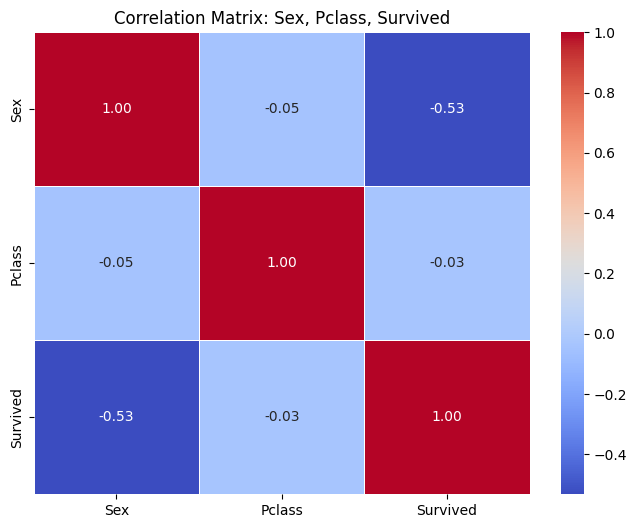

In [16]:
# 3. 성별, 티켓클래스(Pclass), 생존여부(Survived) 상관관계 분석
correlation_matrix = features[['Sex', 'Pclass', 'Survived']].corr()

# 히트맵 그리기
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix: Sex, Pclass, Survived')
plt.show()

4. X_train, y_train, X_test, y_test로 나누고 생존여부(Survived)에 따라 각각 분류(SVM, LR, DT, RT, KNN)

In [17]:
# train & test
# 훈련세트와 테스트세트로 나누기
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(passenger_full, passenger_target, test_size=0.2, stratify=passenger_target, random_state=42)

In [18]:
X.dtypes

Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin         int64
Embarked      int64
dtype: object

In [19]:
from sklearn.preprocessing import StandardScaler

# 데이터 표준화
scaler = StandardScaler()
train_scaled = scaler.fit_transform(X_train)
test_scaled = scaler.transform(X_test)

In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [21]:
# Support Vector Machine (SVM) with Standardization
from sklearn.svm import SVC
svm_model = SVC(random_state=42)
svm_model.fit(train_scaled, y_train)

svm_predictions = svm_model.predict(test_scaled)
svm_accuracy = accuracy_score(y_test, svm_predictions)
print("SVM Accuracy with Standardization:", svm_accuracy)

print("Confusion Matrix:\n", confusion_matrix(y_test, svm_predictions))
print("Classification Report:\n", classification_report(y_test, svm_predictions))

SVM Accuracy with Standardization: 0.7297297297297297
Confusion Matrix:
 [[ 7  5]
 [ 5 20]]
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.58      0.58        12
           1       0.80      0.80      0.80        25

    accuracy                           0.73        37
   macro avg       0.69      0.69      0.69        37
weighted avg       0.73      0.73      0.73        37



In [22]:
# Logistic Regression (LR) with Standardization
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(train_scaled, y_train)

lr_predictions = lr_model.predict(test_scaled)
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy with Standardization:", lr_accuracy)
print("Confusion Matrix:\n", confusion_matrix(y_test, lr_predictions))
print("Classification Report:\n", classification_report(y_test, lr_predictions))

Logistic Regression Accuracy with Standardization: 0.7297297297297297
Confusion Matrix:
 [[ 6  6]
 [ 4 21]]
Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.50      0.55        12
           1       0.78      0.84      0.81        25

    accuracy                           0.73        37
   macro avg       0.69      0.67      0.68        37
weighted avg       0.72      0.73      0.72        37



In [23]:
# Decision Tree (DT) with Standardization
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(train_scaled, y_train)

dt_predictions = dt_model.predict(test_scaled)
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy with Standardization:", dt_accuracy)
print("Confusion Matrix:\n", confusion_matrix(y_test, dt_predictions))
print("Classification Report:\n", classification_report(y_test, dt_predictions))

Decision Tree Accuracy with Standardization: 0.7297297297297297
Confusion Matrix:
 [[ 7  5]
 [ 5 20]]
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.58      0.58        12
           1       0.80      0.80      0.80        25

    accuracy                           0.73        37
   macro avg       0.69      0.69      0.69        37
weighted avg       0.73      0.73      0.73        37



In [24]:
# Random Forest (RF) with Standardization
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(train_scaled, y_train)

rf_predictions = rf_model.predict(test_scaled)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy with Standardization:", rf_accuracy)
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_predictions))
print("Classification Report:\n", classification_report(y_test, rf_predictions))

Random Forest Accuracy with Standardization: 0.7297297297297297
Confusion Matrix:
 [[ 7  5]
 [ 5 20]]
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.58      0.58        12
           1       0.80      0.80      0.80        25

    accuracy                           0.73        37
   macro avg       0.69      0.69      0.69        37
weighted avg       0.73      0.73      0.73        37



In [25]:
# K-Nearest Neighbors (KNN) with Standardization
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier()
knn_model.fit(train_scaled, y_train)

knn_predictions = knn_model.predict(test_scaled)
knn_accuracy = accuracy_score(y_test, knn_predictions)

print("K-Nearest Neighbors Accuracy with Standardization:", knn_accuracy)
print("Confusion Matrix:\n", confusion_matrix(y_test, knn_predictions))
print("Classification Report:\n", classification_report(y_test, knn_predictions))

K-Nearest Neighbors Accuracy with Standardization: 0.7567567567567568
Confusion Matrix:
 [[ 7  5]
 [ 4 21]]
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.58      0.61        12
           1       0.81      0.84      0.82        25

    accuracy                           0.76        37
   macro avg       0.72      0.71      0.72        37
weighted avg       0.75      0.76      0.75        37

